In [2]:
import pandas as pd
import matplotlib
matplotlib.use('TkAgg')  
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("stroke_prediction_dataset.csv", encoding='utf-8')
df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [3]:
def Desc_stat(ds, var):
    mean = ds[var].mean()
    median = ds[var].median()
    mode = ds[var].mode()[0]
    minimum = ds[var].min()
    maximum = ds[var].max()
    range_val = ds[var].max() - ds[var].min()
    std_dev = ds[var].std()
    variance = ds[var].var()
    skew = ds[var].skew()
    kurtosis = ds[var].kurt()
    count = ds[var].count()

    Quart = [
        ds[var].quantile(0),
        ds[var].quantile(0.25),
        ds[var].quantile(0.50),
        ds[var].quantile(0.75),
        ds[var].quantile(1),
        ds[var].quantile(0.75) - ds[var].quantile(0.25)
    ]

    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": range_val,
        "Std Dev": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "Inter Quartile Range": Quart[5],
        "Count": count
    }

    return summary

In [4]:
sample_size = 150
ds = df.sample(n=sample_size,replace =False,random_state=42)
print(ds)

Desc_stat(ds,'Stroke History')

       Patient ID     Patient Name  Age  Gender  Hypertension  Heart Disease  \
11499       10663    Shray Gokhale   71    Male             1              1   
6475        59203      Hridaan Rao   34    Male             0              0   
13167       47760      Ira Kashyap   90  Female             0              1   
862          8564  Hrishita Shetty   30  Female             0              0   
5970         6507     Neysa Bhatti   82    Male             0              0   
...           ...              ...  ...     ...           ...            ...   
2357        14313   Nishith Sandal   68  Female             0              1   
14680        2992      Armaan Chad   46  Female             1              0   
290         81923    Miraya Sekhon   56  Female             0              0   
12534       13858   Armaan Mahajan   86    Male             1              0   
5908        86496        Mehul Bal   87  Female             1              1   

      Marital Status       Work Type Re

{'Average': np.float64(0.5666666666666667),
 'Median': np.float64(1.0),
 'Mode': np.int64(1),
 'Minimum': np.int64(0),
 'Maximum': np.int64(1),
 'Range': np.int64(1),
 'Std Dev': np.float64(0.49719571540626184),
 'Variance': np.float64(0.24720357941834453),
 'Skewness': np.float64(-0.27179464936602526),
 'Kurtosis': np.float64(-1.9523401876343058),
 '25th Percentile': np.float64(0.0),
 '50th Percentile': np.float64(1.0),
 '75th Percentile': np.float64(1.0),
 'Inter Quartile Range': np.float64(1.0),
 'Count': np.int64(150)}

In [5]:
k = len(df) // 150
systematic_sampling = df.iloc[::k]

print(systematic_sampling)

Desc_stat(systematic_sampling,'Stroke History')

       Patient ID      Patient Name  Age  Gender  Hypertension  Heart Disease  \
0           18153   Mamooty Khurana   56    Male             0              1   
100         32109       Oorja Shere   75    Male             0              0   
200         16627       Pihu Sharaf   34  Female             0              0   
300         80371      Kimaya Borra   83  Female             0              1   
400         34615  Zara Viswanathan   86    Male             0              1   
...           ...               ...  ...     ...           ...            ...   
14500        3380       Madhup Apte   39    Male             0              0   
14600       84401        Rati Wable   29  Female             1              0   
14700       12743       Hiran Koshy   60    Male             0              1   
14800         257          Sana Sur   59  Female             0              0   
14900       97026     Yakshit Uppal   84  Female             0              1   

      Marital Status       

{'Average': np.float64(0.52),
 'Median': np.float64(1.0),
 'Mode': np.int64(1),
 'Minimum': np.int64(0),
 'Maximum': np.int64(1),
 'Range': np.int64(1),
 'Std Dev': np.float64(0.5012735458661617),
 'Variance': np.float64(0.2512751677852349),
 'Skewness': np.float64(-0.08087508482118216),
 'Kurtosis': np.float64(-2.0205817080817083),
 '25th Percentile': np.float64(0.0),
 '50th Percentile': np.float64(1.0),
 '75th Percentile': np.float64(1.0),
 'Inter Quartile Range': np.float64(1.0),
 'Count': np.int64(150)}

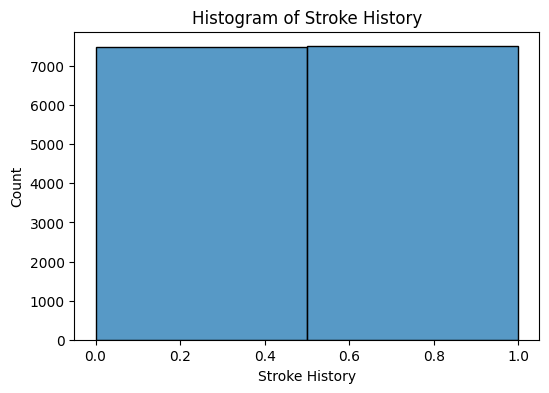

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

dependent_var ='Stroke History'

plt.figure(figsize=(6,4))
sns.histplot(df[dependent_var], bins=2, kde=False)
plt.title('Histogram of Stroke History')
plt.show()

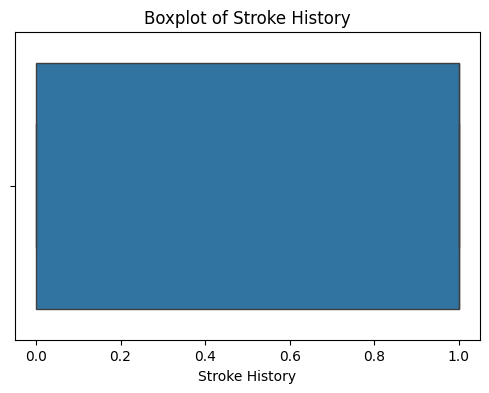

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df[dependent_var])
plt.title('Boxplot of Stroke History')
plt.show()

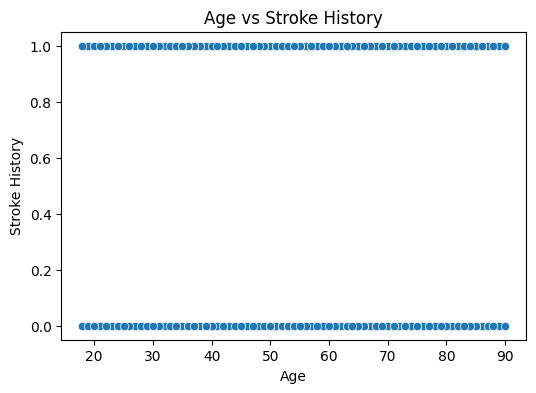

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y=dependent_var, data=df)
plt.title('Age vs Stroke History')
plt.show()

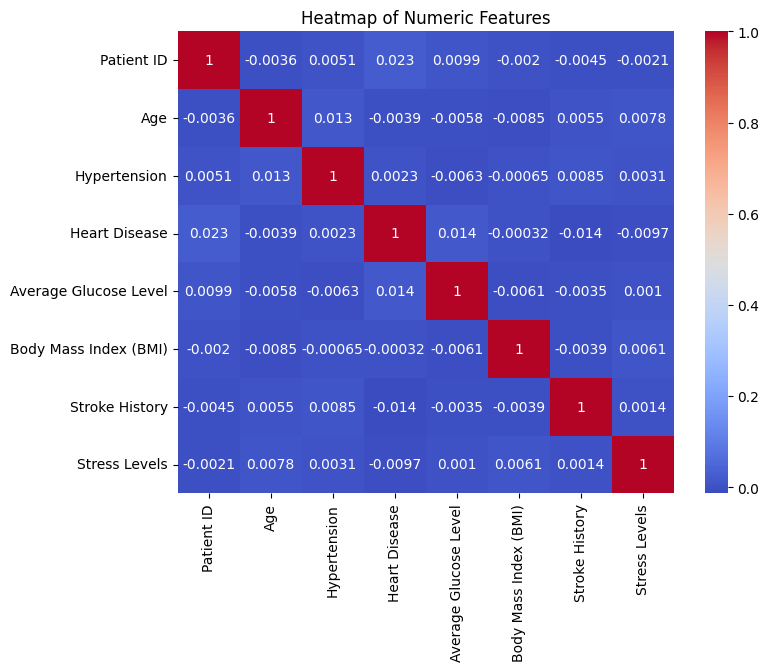

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Numeric Features')
plt.show()

In [10]:
from scipy.stats import pearsonr, spearmanr

alpha = 0.05

r1, p1 = pearsonr(df['Age'], df[dependent_var])
print(f"--- Pearson Correlation (Age vs {dependent_var}) ---")
print(f"Pearson r = {r1:.4f}")
print(f"p-value = {p1:.4f}")

if p1 < alpha:
    print("Decision: Reject H0 (Significant linear relationship exists)")
else:
    print("Decision: Fail to reject H0 (No significant linear relationship)")

print("\n")

--- Pearson Correlation (Age vs Stroke History) ---
Pearson r = 0.0055
p-value = 0.5003
Decision: Fail to reject H0 (No significant linear relationship)




In [11]:
r2, p2 = spearmanr(df['Age'], df[dependent_var])
print(f"--- Spearman Correlation (Age vs {dependent_var}) ---")
print(f"Spearman r = {r2:.4f}")
print(f"p-value = {p2:.4f}")

if p2 < alpha:
    print("Decision: Reject H0 (Significant monotonic relationship exists)")
else:
    print("Decision: Fail to reject H0 (No significant monotonic relationship)")

--- Spearman Correlation (Age vs Stroke History) ---
Spearman r = 0.0055
p-value = 0.5017
Decision: Fail to reject H0 (No significant monotonic relationship)


In [12]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df['Gender'], df['Stroke History'])

chi2, p, dof, expected = chi2_contingency(table)

print("--- Chi-square Test (Gender vs Stroke History) ---")
print("Chi-square value:", round(chi2,4))
print("p-value:", round(p,4))

if p < 0.05:
    print("Decision: Reject H0 (There is a significant association)")
else:
    print("Decision: Fail to reject H0 (Variables are independent)")

--- Chi-square Test (Gender vs Stroke History) ---
Chi-square value: 0.1658
p-value: 0.6838
Decision: Fail to reject H0 (Variables are independent)


In [13]:
from scipy.stats import ttest_1samp

population_mean = df['Age'].mean()

sample = df.sample(n=150, random_state=42)

t_stat, p_value = ttest_1samp(sample['Age'], population_mean)

print("Population mean (Age):", round(population_mean,2))
print("t-statistic:", round(t_stat,4))
print("p-value:", round(p_value,4))

if p_value < 0.05:
    print("Decision: Reject H0 (Sample mean is significantly different)")
else:
    print("Decision: Fail to reject H0 (Sample mean is similar to population mean)")

Population mean (Age): 54.04
t-statistic: 0.2459
p-value: 0.8061
Decision: Fail to reject H0 (Sample mean is similar to population mean)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

df = pd.read_csv("stroke_prediction_dataset.csv")
df.head()

,Patient ID,Patient Name,Age,Gender,Hypertension,Heart Disease,Marital Status,Work Type,Residence Type,Average Glucose Level,...,Alcohol Intake,Physical Activity,Stroke History,Family History of Stroke,Dietary Habits,Stress Levels,Blood Pressure Levels,Cholesterol Levels,Symptoms,Diagnosis
0,18153,Mamooty Khurana,56,Male,0,1,Married,Self-employed,Rural,130.91,...,Social Drinker,Moderate,0,Yes,Vegan,3.48,140/108,"HDL: 68, LDL: 133","Difficulty Speaking, Headache",Stroke
1,62749,Kaira Subramaniam,80,Male,0,0,Single,Self-employed,Urban,183.73,...,Never,Low,0,No,Paleo,1.73,146/91,"HDL: 63, LDL: 70","Loss of Balance, Headache, Dizziness, Confusion",Stroke
2,32145,Dhanush Balan,26,Male,1,1,Married,Never Worked,Rural,189.00,...,Rarely,High,0,Yes,Paleo,7.31,154/97,"HDL: 59, LDL: 95","Seizures, Dizziness",Stroke
3,6154,Ivana Baral,73,Male,0,0,Married,Never Worked,Urban,185.29,...,Frequent Drinker,Moderate,0,No,Paleo,5.35,174/81,"HDL: 70, LDL: 137","Seizures, Blurred Vision, Severe Fatigue, Head...",No Stroke
4,48973,Darshit Jayaraman,51,Male,1,1,Divorced,Self-employed,Urban,177.34,...,Rarely,Low,0,Yes,Pescatarian,6.84,121/95,"HDL: 65, LDL: 68",Difficulty Speaking,Stroke


In [15]:
df.isnull().sum()

df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [17]:
df.columns

Index(['Patient ID', 'Patient Name', 'Age', 'Gender', 'Hypertension',
       'Heart Disease', 'Marital Status', 'Work Type', 'Residence Type',
       'Average Glucose Level', 'Body Mass Index (BMI)', 'Smoking Status',
       'Alcohol Intake', 'Physical Activity', 'Stroke History',
       'Family History of Stroke', 'Dietary Habits', 'Stress Levels',
       'Blood Pressure Levels', 'Cholesterol Levels', 'Symptoms', 'Diagnosis'],
      dtype='object')

In [18]:
# Target Variable
df_encoded['Target'] = df_encoded['Stroke History']
df_encoded.head()

,Patient ID,Age,Hypertension,Heart Disease,Average Glucose Level,Body Mass Index (BMI),Stroke History,Stress Levels,Patient Name_Aaina Arora,Patient Name_Aaina Bahri,...,"Symptoms_Weakness, Weakness, Severe Fatigue, Blurred Vision, Loss of Balance","Symptoms_Weakness, Weakness, Severe Fatigue, Seizures","Symptoms_Weakness, Weakness, Weakness","Symptoms_Weakness, Weakness, Weakness, Headache, Weakness","Symptoms_Weakness, Weakness, Weakness, Loss of Balance","Symptoms_Weakness, Weakness, Weakness, Numbness","Symptoms_Weakness, Weakness, Weakness, Numbness, Difficulty Speaking","Symptoms_Weakness, Weakness, Weakness, Seizures",Diagnosis_Stroke,Target
0,18153,56,0,1,130.91,22.37,0,3.48,False,False,...,False,False,False,False,False,False,False,False,True,0
1,62749,80,0,0,183.73,32.57,0,1.73,False,False,...,False,False,False,False,False,False,False,False,True,0
2,32145,26,1,1,189.00,20.32,0,7.31,False,False,...,False,False,False,False,False,False,False,False,True,0
3,6154,73,0,0,185.29,27.50,0,5.35,False,False,...,False,False,False,False,False,False,False,False,False,0
4,48973,51,1,1,177.34,29.06,0,6.84,False,False,...,False,False,False,False,False,False,False,False,True,0


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Target'])
y = df_encoded['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
Q1 = df_encoded['Age'].quantile(0.25)
Q3 = df_encoded['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_age = df_encoded[(df_encoded['Age'] < lower) | (df_encoded['Age'] > upper)]


Q1 = df_encoded['Average Glucose Level'].quantile(0.25)
Q3 = df_encoded['Average Glucose Level'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_glucose = df_encoded[(df_encoded['Average Glucose Level'] < lower) | (df_encoded['Average Glucose Level'] > upper)]


Q1 = df_encoded['Body Mass Index (BMI)'].quantile(0.25)
Q3 = df_encoded['Body Mass Index (BMI)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_bmi = df_encoded[(df_encoded['Body Mass Index (BMI)'] < lower) | (df_encoded['Body Mass Index (BMI)'] > upper)]

In [22]:
all_outliers = pd.concat([outliers_age, outliers_glucose, outliers_bmi])
all_outliers = all_outliers.drop_duplicates()

In [23]:
df_clean = df_encoded.drop(all_outliers.index)
df_clean.shape

(15000, 30041)

In [24]:
X = df_clean[['Age', 'Average Glucose Level', 'Body Mass Index (BMI)', 'Stress Levels']]

y = df_clean['Target']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 4)
(3000, 4)
(12000,)
(3000,)


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures

# -----------------------------
# Linear Regression
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
# -----------------------------
# Polynomial Regression (Degree 2)
# -----------------------------
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
# -----------------------------
# Ridge Regression
# -----------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
# -----------------------------
# Lasso Regression
# -----------------------------
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
# -----------------------------
# Elastic Net Regression
# -----------------------------
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [28]:
# Polynomial Features

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Linear Regression
# -----------------------------
# Predict target values
y_pred_lr = lr.predict(X_test)
# Calculate evaluation metrics
print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))
# -----------------------------
# Polynomial Regression
# -----------------------------
y_pred_poly = poly_model.predict(X_test_poly)
print("\nPolynomial Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2:", r2_score(y_test, y_pred_poly))
# -----------------------------
# Ridge Regression
# -----------------------------
y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))
# -----------------------------
# Lasso Regression
# -----------------------------
y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))
# -----------------------------
# Elastic Net Regression
# -----------------------------
y_pred_elastic = elastic.predict(X_test)

print("\nElastic Net Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("R2:", r2_score(y_test, y_pred_elastic))

Linear Regression:
MSE: 0.2503444571242015
R2: -0.0015385197882034074

Polynomial Regression:
MSE: 0.2502341939490046
R2: -0.0010973963116045482

Ridge Regression:
MSE: 0.2503444543046096
R2: -0.0015385085080259486

Lasso Regression:
MSE: 0.2500262649760809
R2: -0.00026554695430180963

Elastic Net Regression:
MSE: 0.25004152682642505
R2: -0.0003266041519667251


In [30]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_elastic)
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ]
})

results

,Model,MSE,R2
0,Linear Regression,0.250344,-0.001539
1,Polynomial Regression,0.250234,-0.001097
2,Ridge,0.250344,-0.001539
3,Lasso,0.250026,-0.000266
4,Elastic Net,0.250042,-0.000327


In [31]:
best_model = results.loc[results['R2'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Lasso
MSE      0.250026
R2      -0.000266
Name: 3, dtype: object


In [32]:
# Print Polynomial Regression Equation

print("Polynomial Regression Intercept:", poly_model.intercept_)
print("Polynomial Regression Coefficients:", poly_model.coef_)

Polynomial Regression Intercept: 0.3956936361282176
Polynomial Regression Coefficients: [ 0.00000000e+00  3.24894879e-04  1.26147097e-03  3.49219591e-03
 -1.26393484e-02  4.08171055e-07  1.05366694e-06 -1.63897964e-05
  8.82673788e-06 -2.85757566e-06 -2.30863592e-05 -4.75263736e-06
 -7.38648824e-06  2.04808414e-04  5.43866843e-04]


In [33]:
# Linear Regression Equation
print("Linear Regression Intercept:", lr.intercept_)
print("Linear Regression Coefficients:", lr.coef_)

# Ridge Regression Equation
print("Ridge Intercept:", ridge.intercept_)
print("Ridge Coefficients:", ridge.coef_)

# Lasso Regression Equation
print("Lasso Intercept:", lasso.intercept_)
print("Lasso Coefficients:", lasso.coef_)

# Elastic Net Regression Equation
print("Elastic Net Intercept:", elastic.intercept_)
print("Elastic Net Coefficients:", elastic.coef_)

Linear Regression Intercept: 0.5058535506765958
Linear Regression Coefficients: [ 9.48305739e-05 -8.19527071e-05  2.48117835e-04 -1.68339900e-03]
Ridge Intercept: 0.5058534806989475
Ridge Coefficients: [ 9.48305389e-05 -8.19527047e-05  2.48117329e-04 -1.68338197e-03]
Lasso Intercept: 0.5015418155959601
Lasso Coefficients: [ 0.0000000e+00 -2.1582591e-05  0.0000000e+00 -0.0000000e+00]
Elastic Net Intercept: 0.5055053290208652
Elastic Net Coefficients: [ 0.00000000e+00 -5.22231854e-05  0.00000000e+00 -0.00000000e+00]


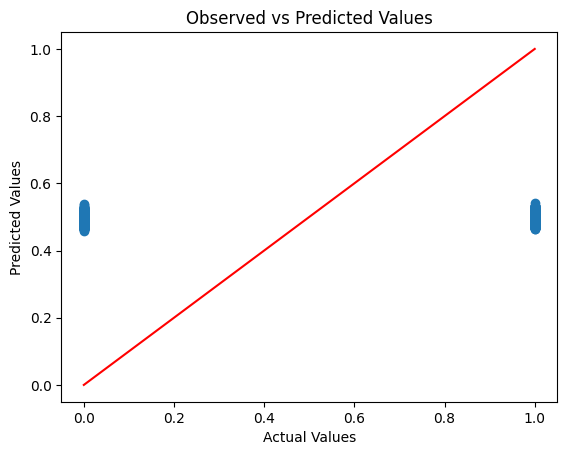

In [34]:
# Plot Observed vs Predicted values

plt.scatter(y_test, y_pred_poly)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted Values")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import sys
import io

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# 1. Load data
df = pd.read_csv("stroke_prediction_dataset.csv", encoding='utf-8')
df.columns = df.columns.str.strip()

# 2. Extract Numbers (BP and Cholesterol)
if 'Blood Pressure Levels' in df.columns:
    bp = df['Blood Pressure Levels'].str.split('/', expand=True).astype(float)
    df['Systolic'], df['Diastolic'] = bp[0], bp[1]

if 'Cholesterol Levels' in df.columns:
    df['HDL'] = df['Cholesterol Levels'].str.extract(r'HDL:\s*(\d+)').astype(float)
    df['LDL'] = df['Cholesterol Levels'].str.extract(r'LDL:\s*(\d+)').astype(float)

# 3. Handle Symptoms 
symptoms_list = ['Headache', 'Confusion', 'Weakness', 'Numbness', 'Seizures', 'Vision']
for symptom in symptoms_list:
    df[f'Has_{symptom}'] = df['Symptoms'].str.contains(symptom, case=False, na=False).astype(int)

# 4. Setup Target
df['Target'] = pd.factorize(df['Stroke History'].astype(str).str.strip())[0]

# 5. Clean & Encode
cols_to_drop = ['Patient ID', 'Patient Name', 'Symptoms', 'Diagnosis', 'Stroke History', 'Target', 'Blood Pressure Levels', 'Cholesterol Levels']
X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
X_raw = X_raw.fillna(X_raw.mean(numeric_only=True))
X_encoded = pd.get_dummies(X_raw, drop_first=True)
y = df['Target']

print(f"Final Dataset Shape: {X_encoded.shape}")

# 6. Training 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

print("\n--- Training Final Models ---")
for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=cv)
    print(f"{name} Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"{name} F1 Score: {f1_score(y, y_pred, average='weighted'):.4f}")

Final Dataset Shape: (15000, 37)

--- Training Final Models ---
Random Forest Accuracy: 0.5000
Random Forest F1 Score: 0.4999
Logistic Regression Accuracy: 0.5015
Logistic Regression F1 Score: 0.5009


Final cleaned shape: (15000, 1005)
NaN check:
 Age                           0
Average Glucose Level         0
Body Mass Index (BMI)         0
Physical Activity_low         0
Physical Activity_moderate    0
                             ..
Stress Levels_9.95            0
Stress Levels_9.96            0
Stress Levels_9.97            0
Stress Levels_9.98            0
Stress Levels_9.99            0
Length: 1005, dtype: int64


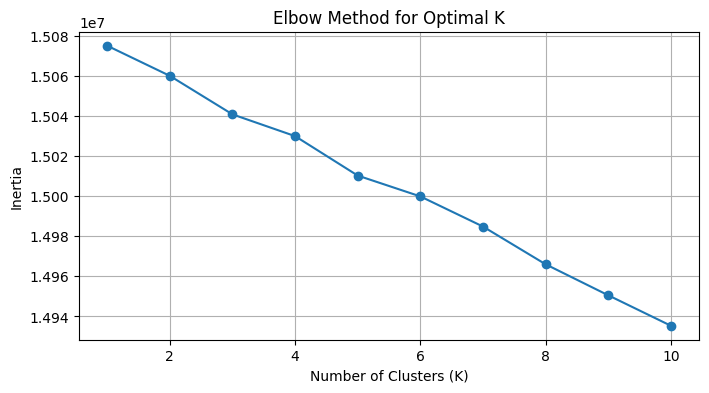

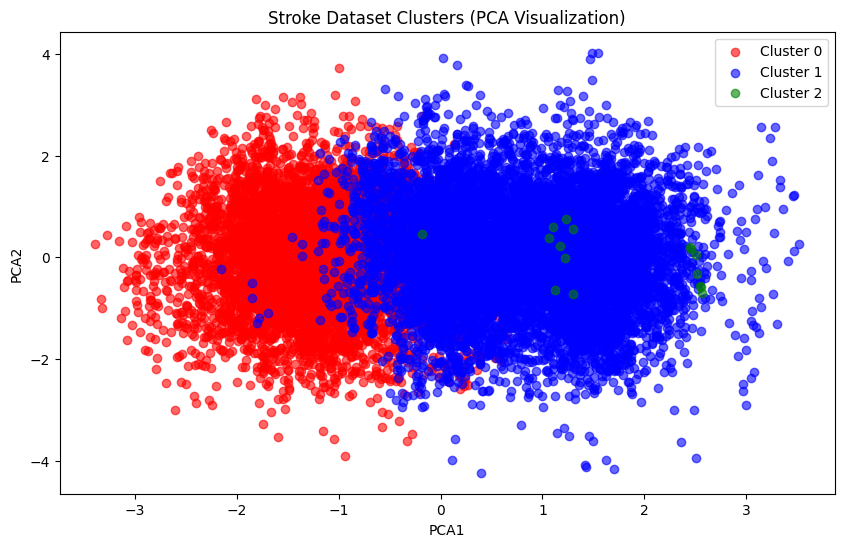


--- Cluster Summary ---
           Patient ID        Age  Hypertension  Heart Disease  \
Cluster                                                         
0        49933.794243  52.931579      0.245066       0.507072   
1        49550.633423  54.786725      0.251685       0.500225   
2        58795.875000  55.625000      0.250000       0.437500   

         Average Glucose Level  Body Mass Index (BMI)  Stroke History  \
Cluster                                                                 
0                   131.081026              27.590377        0.501974   
1                   128.322752              27.392083        0.498989   
2                   132.481875              29.120625        0.562500   

         Stress Levels  Cluster      PCA1      PCA2  
Cluster                                              
0             4.970306      0.0 -1.232530 -0.074378  
1             5.063431      1.0  0.838596  0.050804  
2             2.260000      2.0  1.683079 -0.009195  


In [ ]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# 1. Load dataset
df = pd.read_csv("stroke_prediction_dataset.csv", encoding='utf-8')
df.columns = df.columns.str.strip()

# 2. Select features
features = [
    'Age', 
    'Average Glucose Level', 
    'Body Mass Index (BMI)', 
    'Physical Activity', 
    'Stress Levels'
]

X = df[features].copy()

# 3. Clean text columns 
for col in ['Physical Activity', 'Stress Levels']:
    X[col] = (
        X[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# 4. Convert numeric columns 
numeric_cols = ['Age', 'Average Glucose Level', 'Body Mass Index (BMI)']

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = pd.get_dummies(X, columns=['Physical Activity', 'Stress Levels'], drop_first=True)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

print("Final cleaned shape:", X.shape)

# 7. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8. Elbow method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# 9. Final clustering (K=3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# Align df with cleaned X
df_cleaned = df.loc[X.index].copy()
df_cleaned['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 10. PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df_cleaned['PCA1'] = pca_data[:, 0]
df_cleaned['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']

for i in range(3):
    subset = df_cleaned[df_cleaned['Cluster'] == i]
    plt.scatter(
        subset['PCA1'],
        subset['PCA2'],
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.6
    )

plt.title('Stroke Dataset Clusters (PCA Visualization)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

# 11. Cluster Summary
print("\n--- Cluster Summary ---")

numeric_summary = df_cleaned.select_dtypes(include=[np.number])

print(numeric_summary.groupby(df_cleaned['Cluster']).mean())